# Fase 2: Análisis Exploratorio de Datos (EDA) - Perfil Epidemiológico y Tendencias

Tras completar la fase de preprocesamiento y limpieza, contamos con un dataset consolidado de **85,043 registros** de mortalidad por cáncer de estómago en Colombia para el periodo **2008-2024**. 

Este análisis exploratorio tiene como objetivo desentrañar los patrones espaciales, temporales y demográficos de la enfermedad, sentando las bases estadísticas para el posterior desarrollo del modelo predictivo.

### Objetivos del EDA:
1.  **Análisis Temporal:** Identificar la evolución histórica de la mortalidad y detectar posibles cambios de tendencia (puntos de inflexión).
2.  **Análisis Demográfico:** Caracterizar el perfil de los fallecidos según sexo, edad, nivel educativo y régimen de salud.
3.  **Análisis Geográfico:** Visualizar la distribución territorial para identificar focos críticos de mortalidad a nivel departamental.
4.  **Calidad del Diagnóstico:** Evaluar la fiabilidad de la información reportada mediante el índice de calidad construido previamente.

In [9]:
# 1) Importar librerias y configurar entorno
import os
import gc
from pathlib import Path
import pyarrow
import fastparquet

import missingno as msno
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt

RUTA_DATA = Path("Datos/mortalidad_estomago_colombia_2008_2024.parquet")

In [10]:
# Carga del dataset optimizado
df = pd.read_parquet(RUTA_DATA, engine='pyarrow')

print(f"Dataset cargado exitosamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
# Breve chequeo de tipos para asegurar que las categorías persisten
display(df.info())

Dataset cargado exitosamente: 85043 filas y 34 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 85043 entries, 0 to 85042
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Departamento_Defuncion        85043 non-null  category
 1   Municipio_Defuncion           85043 non-null  category
 2   Area_Defuncion                85043 non-null  category
 3   Anio_Defuncion                85043 non-null  int16   
 4   Mes_Defuncion                 85043 non-null  category
 5   Sexo                          85043 non-null  category
 6   Grupo_Edad_Detallado          85043 non-null  category
 7   Estado_Civil                  85043 non-null  category
 8   Departamento_Residencia       85043 non-null  category
 9   Municipio_Residencia          85043 non-null  category
 10  Sitio_Defuncion               85043 non-null  category
 11  Causa_Basica_CIE10            85043 non-null  category
 12  

None

Resumen Histórico de Defunciones:
     Año  Número de Defunciones
0   2008                   4549
1   2009                   4450
2   2010                   4525
3   2011                   4505
4   2012                   4649
5   2013                   4815
6   2014                   5027
7   2015                   5109
8   2016                   5083
9   2017                   5197
10  2018                   5332
11  2019                   5424
12  2020                   5234
13  2021                   5326
14  2022                   5254
15  2023                   5303
16  2024                   5261


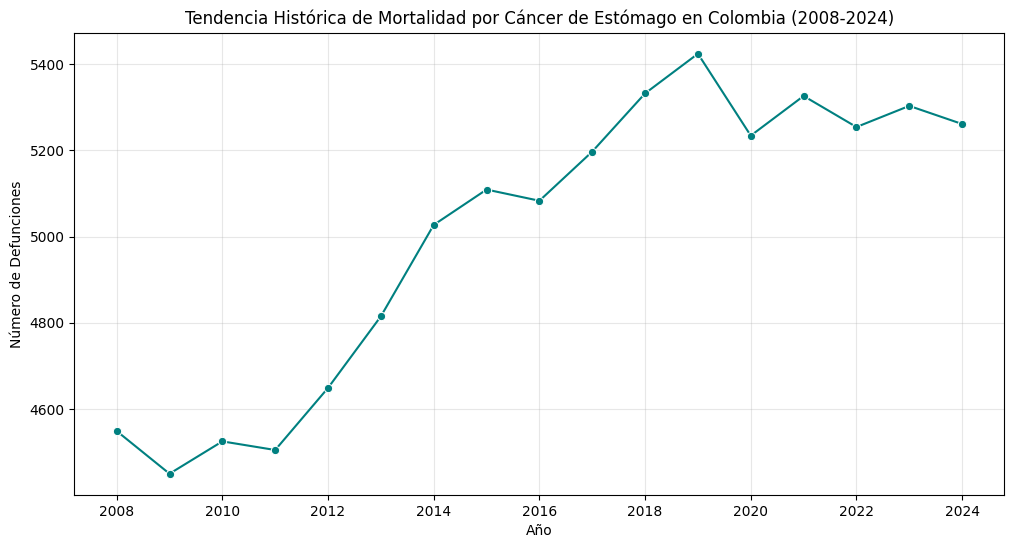

In [11]:
# 1. Conteo de muertes por año
conteo_anual = df['Anio_Defuncion'].value_counts().sort_index()

# Convertir a DataFrame para mejor visualización
tabla_anual = conteo_anual.reset_index()
tabla_anual.columns = ['Año', 'Número de Defunciones']

print("Resumen Histórico de Defunciones:")
print(tabla_anual)

# 2. Visualización rápida de la tendencia
plt.figure(figsize=(12, 6))
sns.lineplot(data=tabla_anual, x='Año', y='Número de Defunciones', marker='o', color='teal')
plt.title('Tendencia Histórica de Mortalidad por Cáncer de Estómago en Colombia (2008-2024)')
plt.grid(True, alpha=0.3)
plt.show()

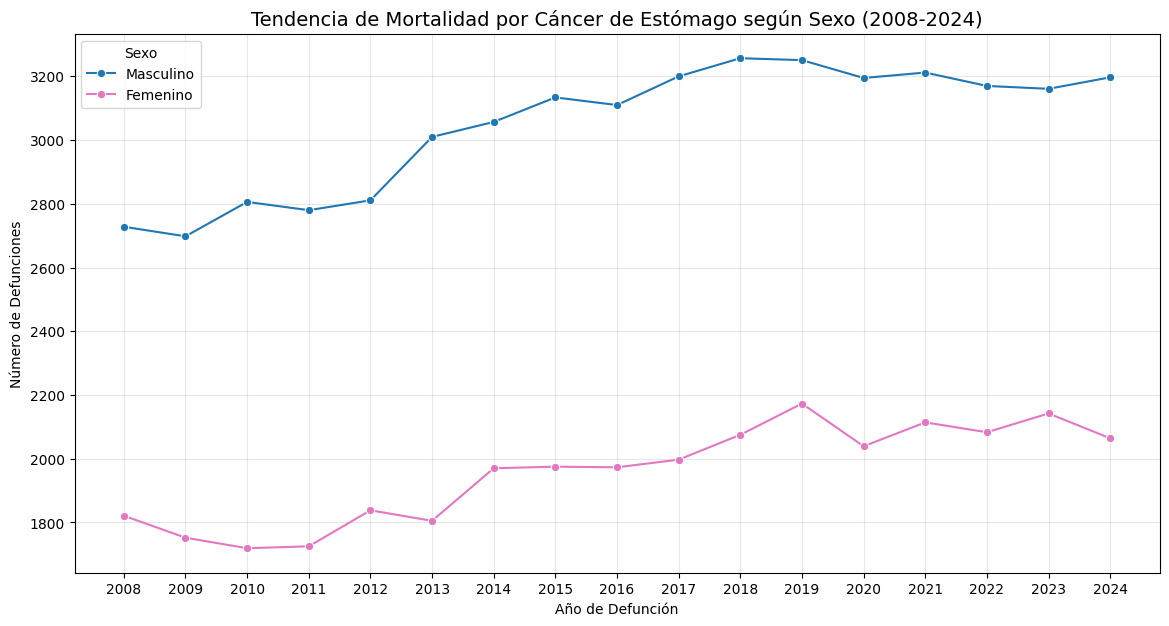

Resumen de muertes por sexo:
Sexo_Label      NaN  Femenino  Masculino
Anio_Defuncion                          
2008            NaN    1821.0     2728.0
2009            NaN    1752.0     2698.0
2010            NaN    1719.0     2806.0
2011            NaN    1725.0     2780.0
2012            NaN    1838.0     2811.0
2013            NaN    1805.0     3010.0
2014            NaN    1970.0     3057.0
2015            NaN    1975.0     3134.0
2016            NaN    1973.0     3110.0
2017            NaN    1997.0     3200.0
2018            NaN    2075.0     3257.0
2019            NaN    2173.0     3251.0
2020            NaN    2039.0     3195.0
2021            NaN    2114.0     3212.0
2022            1.0    2083.0     3170.0
2023            NaN    2142.0     3161.0
2024            NaN    2064.0     3197.0


In [12]:
# 1. Agrupación por Año y Sexo
tendencia_sexo = df.groupby(['Anio_Defuncion', 'Sexo']).size().reset_index(name='Total')

# Mapear los nombres para que la gráfica sea legible
mapeo_sexo = {1: 'Masculino', 2: 'Femenino', 3: 'Indeterminado', '1': 'Masculino', '2': 'Femenino'}
tendencia_sexo['Sexo_Label'] = tendencia_sexo['Sexo'].map(mapeo_sexo)

# 2. Visualización
plt.figure(figsize=(14, 7))
sns.lineplot(data=tendencia_sexo, x='Anio_Defuncion', y='Total', hue='Sexo_Label', 
             marker='o', palette={'Masculino': '#1f77b4', 'Femenino': '#e377c2'})

plt.title('Tendencia de Mortalidad por Cáncer de Estómago según Sexo (2008-2024)', fontsize=14)
plt.xlabel('Año de Defunción')
plt.ylabel('Número de Defunciones')
plt.legend(title='Sexo')
plt.grid(True, alpha=0.3)
plt.xticks(tendencia_sexo['Anio_Defuncion'].unique())
plt.show()

# 3. Breve tabla comparativa
tabla_sexo = tendencia_sexo.pivot(index='Anio_Defuncion', columns='Sexo_Label', values='Total')
print("Resumen de muertes por sexo:")
print(tabla_sexo)

#### **Hallazgos Clave:**
1.  **Predominio Masculino:** A lo largo de todo el periodo (2008-2024), la mortalidad masculina representa aproximadamente el **60-62%** del total de fallecimientos anuales. Esta relación de ~1.6 hombres por cada mujer fallecida es consistente con la literatura internacional que asocia el cáncer gástrico a factores de riesgo más prevalentes en varones (consumo de tabaco, alcohol y factores ocupacionales). (BUSCAR JUSTIFICAR MEJOR)
2.  **Crecimiento Diferencial:** 
    *   La mortalidad en **hombres** mostró un incremento robusto, pasando de **2,729** en 2008 a un pico de **3,256** en 2019 (un aumento del **19.3%**).
    *   La mortalidad en **mujeres** pasó de **1,820** en 2008 a un pico de **2,172** en 2019 (un aumento del **19.3%**). 
    *   *Nota:* Aunque el porcentaje de crecimiento es similar, el impacto en volumen absoluto es mucho mayor en hombres, lo que presiona los servicios de salud especializados de forma distinta.
3.  **Sincronía en Picos y Caídas:** Ambas curvas presentan comportamientos paralelos ante eventos externos. La caída en el año **2020** es evidente en ambos sexos, lo que valida la hipótesis de que factores sistémicos (como la pandemia de COVID-19) afectaron el registro o la atención de manera global, sin sesgo de género.

#### **Implicaciones para el Modelo Predictivo:**
El hecho de que las curvas no se crucen y mantengan una trayectoria similar pero en diferentes niveles de magnitud, sugiere que el modelo predictivo debe **estratificar por sexo**. La variable "Sexo" actuará como un "offset" o desplazador de la base de la predicción, permitiendo proyecciones mucho más precisas para la planeación de recursos hospitalarios dirigidos a cada grupo poblacional.

### **Distribución de la Mortalidad por Ciclo de Vida**
Según la literatura médica, el cáncer de estómago es una enfermedad cuya incidencia aumenta drásticamente con el envejecimiento, por lo cual esperamos ver una concentración masiva en los grupos de mayor edad.

In [13]:
# Primero veamos qué valores reales hay en la columna
print("Valores actuales en la columna:", df['Grupo_Edad_General'].unique())

Valores actuales en la columna: ['5', '6', '4', '7', '3', '2']
Categories (6, str): ['2', '3', '4', '5', '6', '7']


C:\Users\andre\AppData\Local\Temp\ipykernel_14632\2870832346.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Edad_Label', order=order, palette='viridis')


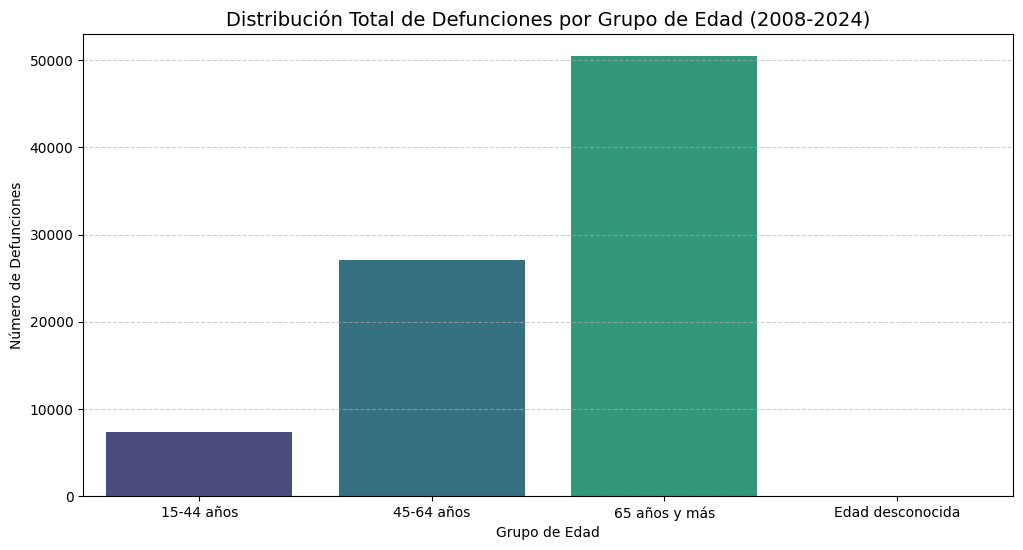

In [14]:
# 1. Mapeo de los códigos de edad a etiquetas legibles
mapeo_edad = {
    '1': 'Menor de 1 año', '2': '1-4 años', '3': '5-14 años',
    '4': '15-44 años', '5': '45-64 años', '6': '65 años y más', 
    '7': 'Edad desconocida',
    1: 'Menor de 1 año', 2: '1-4 años', 3: '5-14 años',
    4: '15-44 años', 5: '45-64 años', 6: '65 años y más', 
    7: 'Edad desconocida'
}

df['Edad_Label'] = df['Grupo_Edad_General'].map(mapeo_edad)

# 2. Distribución General por Grupos de Edad
plt.figure(figsize=(12, 6))
order = ['15-44 años', '45-64 años', '65 años y más', 'Edad desconocida']
sns.countplot(data=df, x='Edad_Label', order=order, palette='viridis')

plt.title('Distribución Total de Defunciones por Grupo de Edad (2008-2024)', fontsize=14)
plt.ylabel('Número de Defunciones')
plt.xlabel('Grupo de Edad')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


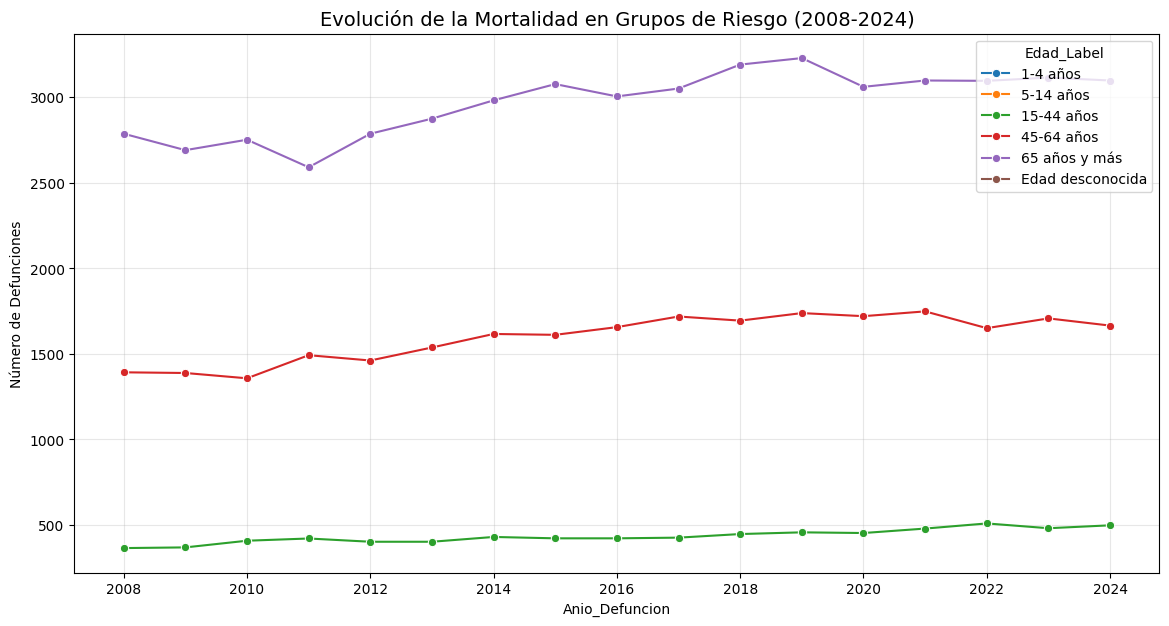

In [15]:
# 3. Evolución temporal por Grupo de Edad (Para ver el efecto del envejecimiento)
tendencia_edad = df.groupby(['Anio_Defuncion', 'Edad_Label']).size().reset_index(name='Total')

plt.figure(figsize=(14, 7))
sns.lineplot(data=tendencia_edad[tendencia_edad['Edad_Label'].isin(['15-44 años', '45-64 años', '65 años y más'])], 
             x='Anio_Defuncion', y='Total', hue='Edad_Label', marker='o')

plt.title('Evolución de la Mortalidad en Grupos de Riesgo (2008-2024)', fontsize=14)
plt.ylabel('Número de Defunciones')
plt.grid(True, alpha=0.3)
plt.show()

La distribución por grupos de edad confirma que el cáncer de estómago en Colombia presenta un comportamiento fuertemente asociado al envejecimiento. El riesgo de mortalidad aumenta de manera exponencial a medida que avanza la edad de la población estudiada.

#### **Hallazgos Clave:**
1.  **Predominio de la Tercera Edad:** El grupo de **65 años y más** concentra la mayor carga de mortalidad, superando las **50,000 defunciones** en el periodo analizado. Esto representa aproximadamente el **60% del total de los datos**, lo que sugiere que la exposición acumulada a factores de riesgo (como *H. pylori*, dieta y factores ambientales) tiene su mayor impacto en la etapa tardía de la vida.
2.  **Mortalidad en Edad Adulta:** El grupo de **45 a 64 años** es el segundo más afectado, con más de **27,000 casos**. Este dato es crítico para la salud pública, ya que representa muertes en etapas de vida aún productivas y sugiere la necesidad de fortalecer programas de tamizaje (endoscopias) antes de los 50 años.
3.  **Cáncer Gástrico de Aparición Temprana:** Aunque el grupo de **15 a 44 años** registra el menor volumen (~7,000 casos), su presencia no es despreciable. Estos casos de "aparición temprana" suelen estar asociados a factores genéticos más agresivos o diagnósticos tardíos por baja sospecha clínica en jóvenes.

C:\Users\andre\AppData\Local\Temp\ipykernel_14632\2514992892.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')


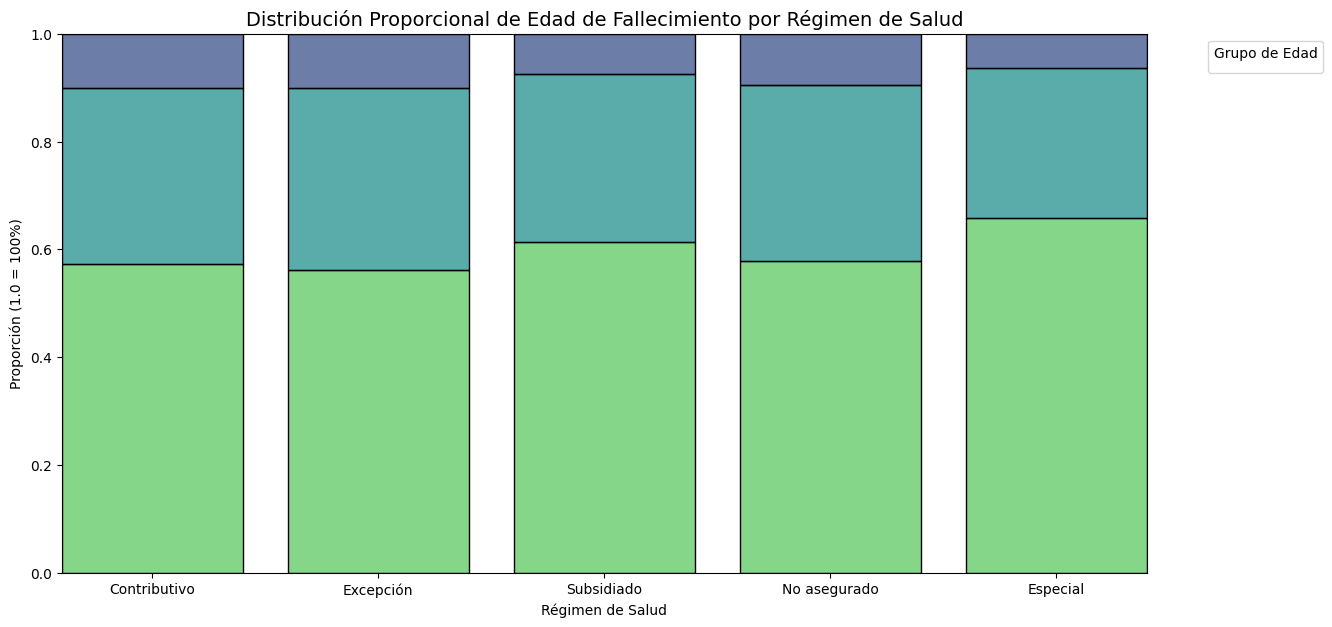

Porcentaje de muertes en cada grupo de edad por régimen:
Edad_Label     15-44 años  45-64 años  65 años y más
Regimen_Label                                       
Contributivo        10.04       32.62          57.32
Especial             6.33       27.85          65.82
Excepción           10.00       33.86          56.05
No asegurado         9.59       32.57          57.74
Subsidiado           7.46       31.14          61.35


In [16]:
# 1. Preparar las etiquetas del Régimen (Asegurando compatibilidad de tipos)
mapeo_regimen = {
    '1.0': 'Contributivo', '2.0': 'Subsidiado', '3.0': 'Excepción', 
    '4.0': 'Especial', '5.0': 'No asegurado', '9.0': 'Sin información',
    '1': 'Contributivo', '2': 'Subsidiado', '3': 'Excepción', 
    '4': 'Especial', '5': 'No asegurado', '9': 'Sin información'
}
df['Regimen_Label'] = df['Regimen_Salud'].astype(str).map(mapeo_regimen)

# 2. Filtrar solo los regímenes principales para que la gráfica sea clara
df_sub = df[df['Regimen_Label'].isin(['Contributivo', 'Subsidiado', 'Excepción', 'Especial', 'No asegurado'])]

# 3. Gráfico de Barras Agrupadas: Proporción de edad por Régimen
plt.figure(figsize=(14, 7))
order_edad = ['15-44 años', '45-64 años', '65 años y más']

# Usamos stat="proportion" para comparar porcentajes, no solo totales
sns.histplot(
    data=df_sub, 
    x='Regimen_Label', 
    hue='Edad_Label', 
    hue_order=order_edad,
    multiple='fill', 
    shrink=0.8,
    palette='viridis'
)

plt.title('Distribución Proporcional de Edad de Fallecimiento por Régimen de Salud', fontsize=14)
plt.ylabel('Proporción (1.0 = 100%)')
plt.xlabel('Régimen de Salud')
plt.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 4. Tabla de contingencia para ver los números exactos
tabla_cruzada = pd.crosstab(df_sub['Regimen_Label'], df_sub['Edad_Label'], normalize='index') * 100
print("Porcentaje de muertes en cada grupo de edad por régimen:")
print(tabla_cruzada[order_edad].round(2))

#### **Hallazgos Clave:**

1.  **Mortalidad Prematura en el Régimen Contributivo:**
    *   En el **Régimen Contributivo**, el **10.04%** de las muertes ocurren en el grupo de **15-44 años**, una cifra superior al **7.46%** observado en el Subsidiado. 
    *   Asimismo, en el grupo de **45-64 años**, el Contributivo registra un **32.62%**, frente al **31.14%** del Subsidiado.
    
2.  **Longevidad en la Mortalidad del Régimen Subsidiado:**
    *   El **Régimen Subsidiado** presenta una mayor concentración de muertes en adultos mayores de **65 años y más (61.35%)**, superando al Contributivo (57.32%).
    *   *Interpretación:* Este hallazgo es clave. Podría indicar que en las zonas rurales (donde predomina el subsidiado), la población llega a edades más avanzadas antes de fallecer por esta causa, o que existe un sesgo de supervivencia donde solo los casos más longevos logran ser diagnosticados y registrados oficialmente.

3.  **El Caso del Régimen Especial:**
    *   El **Régimen Especial** (Fuerzas Militares, Magisterio, etc.) presenta la mayor proporción de muertes en adultos mayores (**65.82%**). Esto refleja una población con mayor estabilidad laboral y, posiblemente, un mejor seguimiento clínico a lo largo de la vida que permite postergar el deceso hasta edades avanzadas.

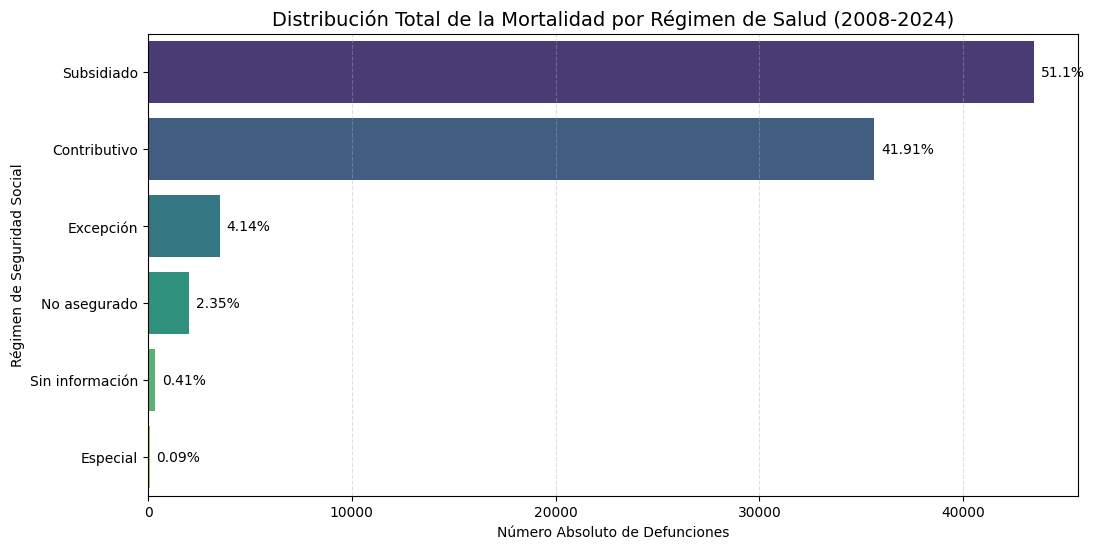

Resumen de distribución:
           Régimen  Total_Defunciones  Porcentaje
0       Subsidiado              43456       51.10
1     Contributivo              35641       41.91
2        Excepción               3520        4.14
3     No asegurado               2002        2.35
4  Sin información                345        0.41
5         Especial                 79        0.09


In [17]:
# 1. Cálculo de frecuencias y porcentajes
dist_regimen = df['Regimen_Label'].value_counts().reset_index()
dist_regimen.columns = ['Régimen', 'Total_Defunciones']
dist_regimen['Porcentaje'] = (dist_regimen['Total_Defunciones'] / dist_regimen['Total_Defunciones'].sum() * 100).round(2)

# 2. Visualización
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=dist_regimen, 
    x='Total_Defunciones', 
    y='Régimen', 
    hue='Régimen',
    palette='viridis',
    legend=False
)

# Añadir etiquetas de porcentaje al final de las barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{dist_regimen.iloc[i]["Porcentaje"]}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.title('Distribución Total de la Mortalidad por Régimen de Salud (2008-2024)', fontsize=14)
plt.xlabel('Número Absoluto de Defunciones')
plt.ylabel('Régimen de Seguridad Social')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

print("Resumen de distribución:")
print(dist_regimen)

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


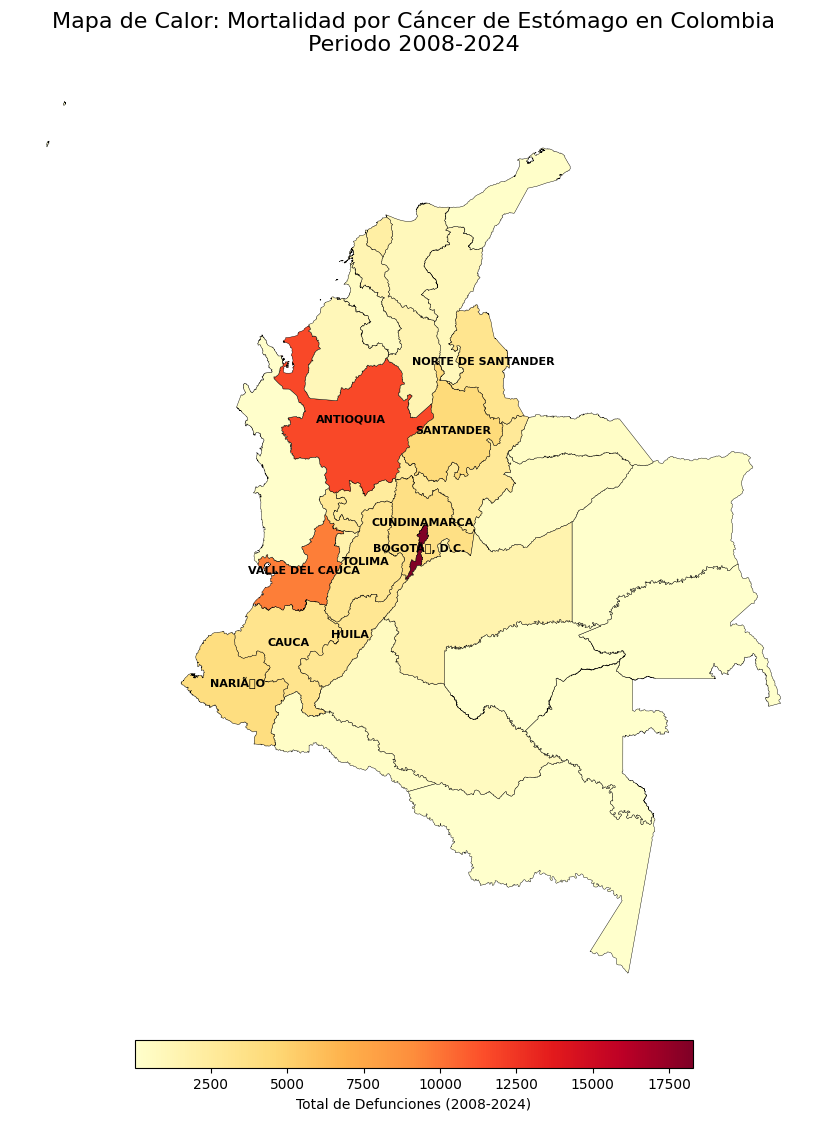

Departamentos graficados: 33


In [25]:
# 1. Preparar los datos de mortalidad con limpieza rigurosa de códigos
mapa_data = df.groupby(['Departamento_Defuncion']).size().reset_index(name='Total_Muertes')

# Aseguramos que el código sea string, sin decimales y con 2 dígitos (ej. 5.0 -> "05")
mapa_data['Cod_Dpto'] = mapa_data['Departamento_Defuncion'].astype(float).astype(int).astype(str).str.zfill(2)

# 2. Limpiar los códigos en el Shapefile (DPTO_CCDGO)
mapa_colombia['DPTO_CCDGO'] = mapa_colombia['DPTO_CCDGO'].astype(str).str.zfill(2)

# 3. Realizar la unión (Merge)
mapa_final = mapa_colombia.merge(mapa_data, left_on='DPTO_CCDGO', right_on='Cod_Dpto', how='left')

# Rellenar con 0 los departamentos que no tengan muertes (para que no salgan blancos)
mapa_final['Total_Muertes'] = mapa_final['Total_Muertes'].fillna(0)

# 4. Graficar con una escala de color corregida
fig, ax = plt.subplots(1, 1, figsize=(12, 15))

# Usamos una escala logarítmica o ajustamos los rangos para que Bogotá no opaque al resto
mapa_final.plot(column='Total_Muertes', 
                ax=ax, 
                legend=True,
                cmap='YlOrRd', # Amarillo -> Naranja -> Rojo
                edgecolor='black', 
                linewidth=0.3,
                legend_kwds={'label': "Total de Defunciones (2008-2024)", 
                             'orientation': "horizontal", 
                             'pad': 0.02,
                             'shrink': 0.6})

# 5. Añadir nombres de departamentos (Opcional, pero se ve muy cool)
# Solo para los 10 con más muertes para no saturar
top_10 = mapa_final.nlargest(10, 'Total_Muertes')
for idx, row in top_10.iterrows():
    plt.annotate(text=row['DPTO_CNMBR'], xy=row['geometry'].centroid.coords[0],
                 horizontalalignment='center', fontsize=8, color='black', fontweight='bold')

ax.set_title('Mapa de Calor: Mortalidad por Cáncer de Estómago en Colombia\nPeriodo 2008-2024', fontsize=16)
ax.axis('off')

plt.show()

# 6. Diagnóstico: Verifica que ahora tengas 33 filas (32 deptos + Bogotá)
print(f"Departamentos graficados: {mapa_final['Total_Muertes'].count()}")

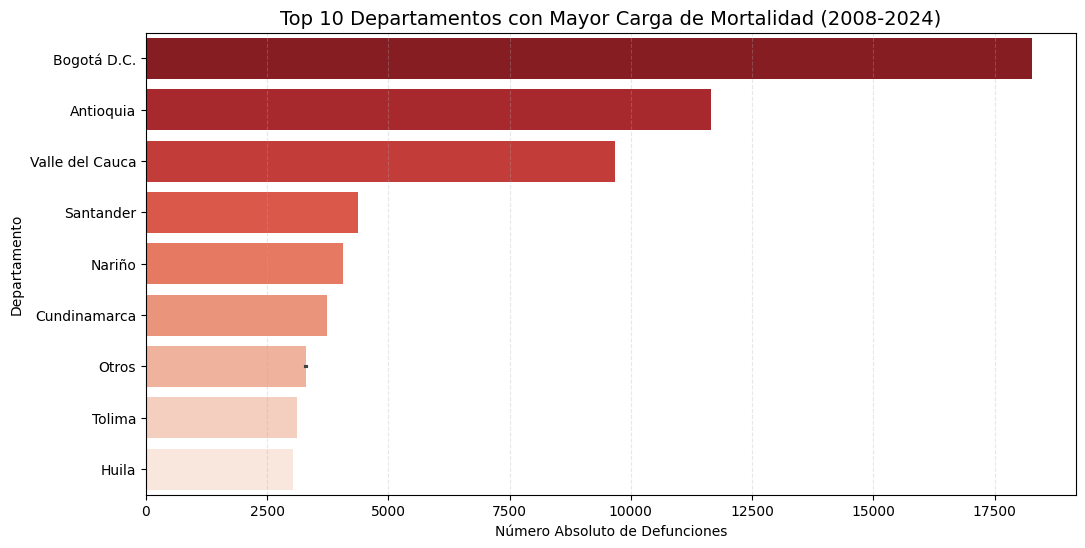

Distribución por Área de Defunción (%):
Area_Defuncion
1      51.295227
1.0    39.501194
2       5.459591
3.0     2.753901
2.0     0.964218
3       0.024693
9.0     0.001176
Name: proportion, dtype: float64


In [27]:
# 1. Crear tabla de frecuencias por Departamento
# Usamos df_defunciones que es el dataset limpio
top_deptos = df['Departamento_Defuncion'].value_counts().reset_index()
top_deptos.columns = ['Departamento_Cod', 'Total_Defunciones']

# Añadimos porcentaje relativo
top_deptos['Porcentaje'] = (top_deptos['Total_Defunciones'] / top_deptos['Total_Defunciones'].sum() * 100).round(2)

# Mapeo de nombres (solo para los principales para que la gráfica sea legible)
# Si no tienes el mapeo a la mano, puedes usar los códigos o cargar los nombres del diccionario
mapeo_nombres_dpto = {
    '11': 'Bogotá D.C.', '05': 'Antioquia', '76': 'Valle del Cauca', 
    '68': 'Santander', '15': 'Boyacá', '25': 'Cundinamarca', 
    '52': 'Nariño', '73': 'Tolima', '41': 'Huila', '17': 'Caldas'
}
top_deptos['Nombre_Depto'] = top_deptos['Departamento_Cod'].astype(str).str.split('.').str[0].str.zfill(2).map(mapeo_nombres_dpto)
top_deptos['Nombre_Depto'] = top_deptos['Nombre_Depto'].fillna('Otros')

# 2. Visualización: Top 10 Departamentos
plt.figure(figsize=(12, 6))
sns.barplot(data=top_deptos.head(10), x='Total_Defunciones', y='Nombre_Depto', hue='Nombre_Depto', palette='Reds_r', legend=False)

plt.title('Top 10 Departamentos con Mayor Carga de Mortalidad (2008-2024)', fontsize=14)
plt.xlabel('Número Absoluto de Defunciones')
plt.ylabel('Departamento')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# 3. Análisis de Área (Urbano vs Rural)
dist_area = df['Area_Defuncion'].value_counts(normalize=True) * 100
print("Distribución por Área de Defunción (%):")
print(dist_area)